               precision    recall  f1-score   support

       Normal       0.91      0.87      0.89        82
Heart Disease       0.90      0.93      0.91       102

     accuracy                           0.90       184
    macro avg       0.90      0.90      0.90       184
 weighted avg       0.90      0.90      0.90       184



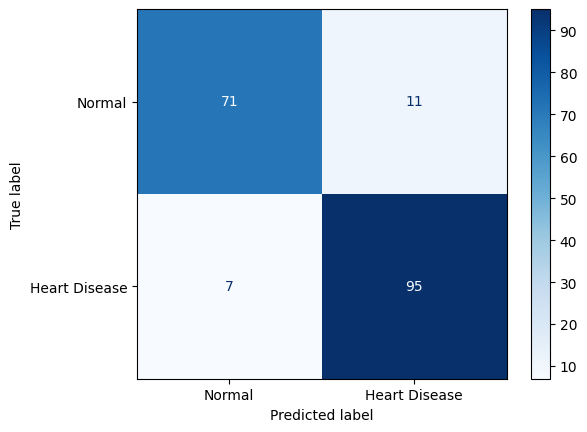


=== TOP FEATURE IMPORTANCES ===
ST_Slope             0.313341
ExerciseAngina       0.130503
Oldpeak              0.109673
MaxHR                0.099015
ChestPainType_ATA    0.070542
dtype: float64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


train = pd.read_csv("../1-Data/train_processed.csv")
test = pd.read_csv("../1-Data/test_processed.csv")

X_train = train.drop(columns=["HeartDisease"])
y_train = train["HeartDisease"]
X_test = test.drop(columns=["HeartDisease"])
y_test = test["HeartDisease"]


rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)


print(classification_report(y_test, y_pred, target_names=["Normal", "Heart Disease"]))


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Heart Disease"])
disp.plot(cmap="Blues")
plt.show()


importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
print("\n=== TOP FEATURE IMPORTANCES ===")
print(feat_importances.head(5))